Train shape: (668665, 15)
Test shape: (286571, 14)

FIRST 5 ROWS
   id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66            92887.0              23.4                     2   
1   1   38            30000.0               5.0                     1   
2   2   26            94389.0              36.8                     1   
3   3   66            73580.0              23.7                     2   
4   4   54            57898.0              50.8                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                          1.0    Male  Suburban

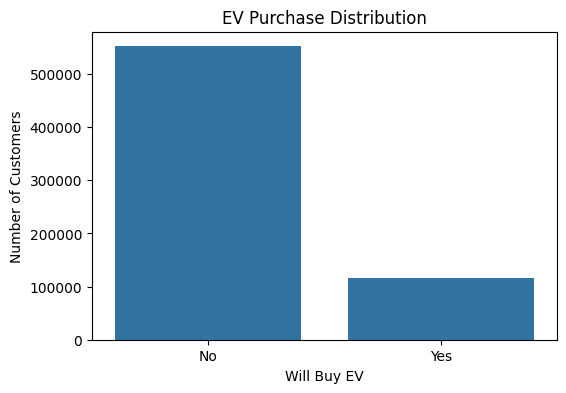

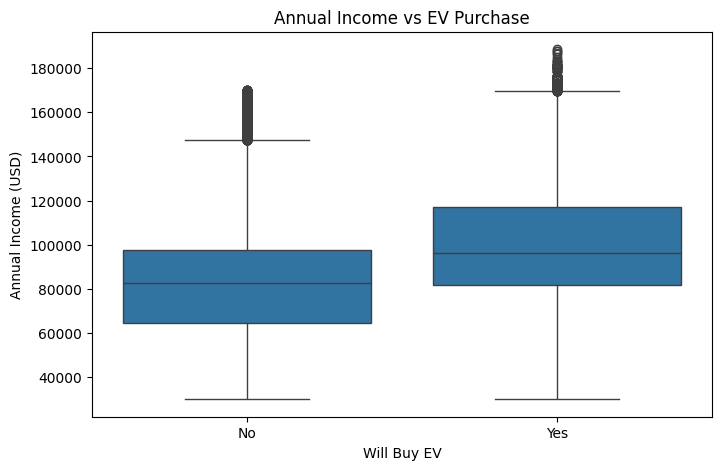

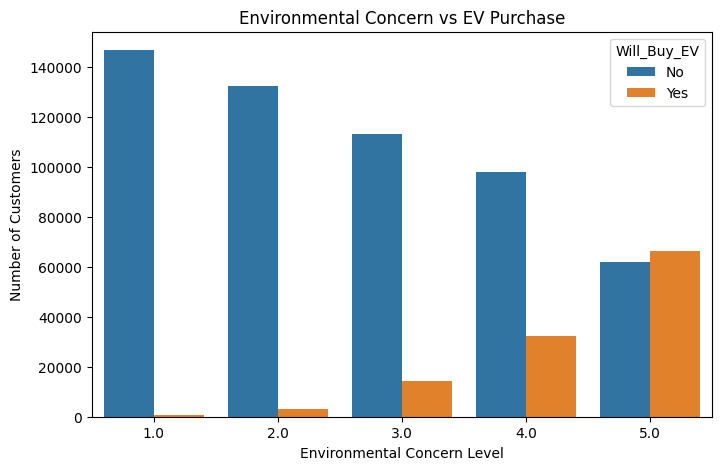

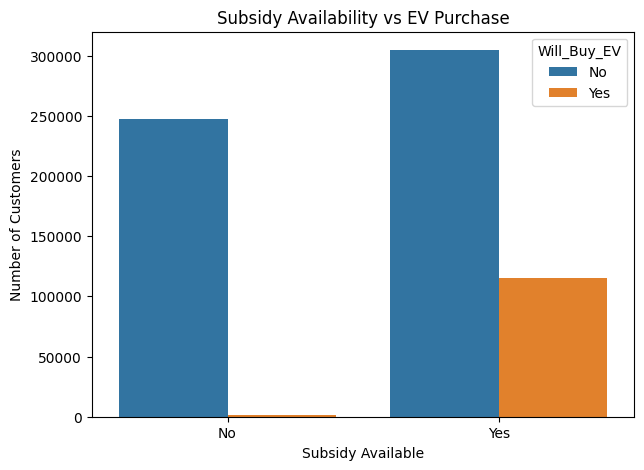

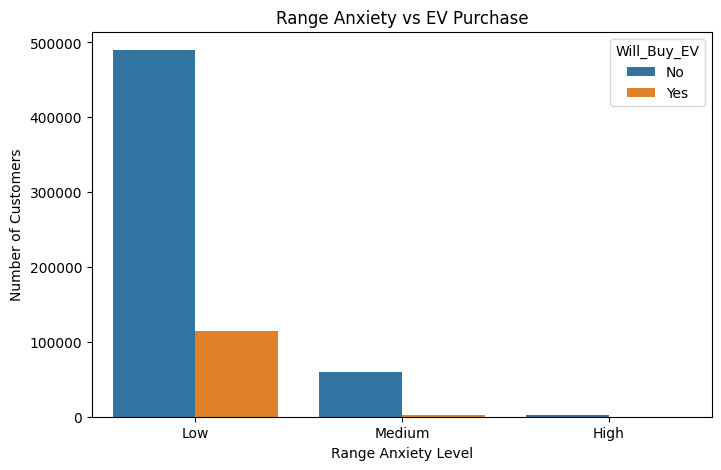

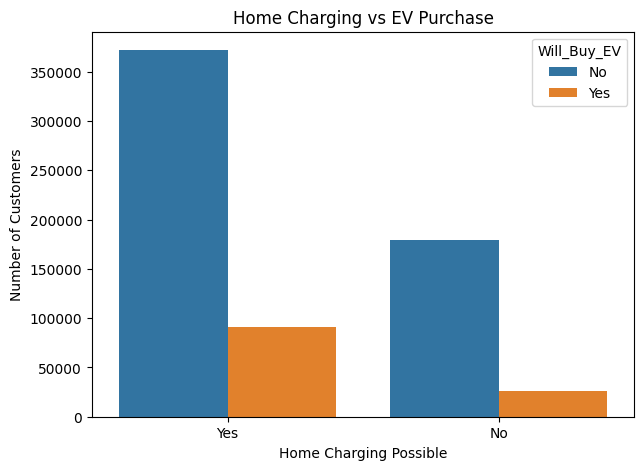

Feature shape: (668665, 13)
Target shape: (668665,)
Numerical features: 7
Categorical features: 6
Training shape: (534932, 13)
Validation shape: (133733, 13)
Logistic Regression ROC-AUC: 0.93796
Encoded training shape: (534932, 24)
Encoded validation shape: (133733, 24)
XGBoost Depth 5 ROC-AUC: 0.94172

========== FOLD 1 ==========
Fold 1: ROC-AUC = 0.94079

========== FOLD 2 ==========
Fold 2: ROC-AUC = 0.94163

========== FOLD 3 ==========
Fold 3: ROC-AUC = 0.94303

========== FOLD 4 ==========
Fold 4: ROC-AUC = 0.94248

========== FOLD 5 ==========
Fold 5: ROC-AUC = 0.94189

XGBOOST DEPTH 5 RESULTS
-----------------------------
Fold 1: 0.94079
Fold 2: 0.94163
Fold 3: 0.94303
Fold 4: 0.94248
Fold 5: 0.94189

Mean ROC-AUC: 0.94196
Std ROC-AUC: 0.00076

========== FINAL MODEL - FOLD 1 ==========
Fold 1 test predictions generated.

========== FINAL MODEL - FOLD 2 ==========
Fold 2 test predictions generated.

========== FINAL MODEL - FOLD 3 ==========
Fold 3 test predictions generated.


In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from catboost import CatBoostClassifier
import lightgbm as lgb


# LOAD THE DATA

train = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e9/train.csv"
)

test = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e9/test.csv"
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


# INSPECT THE DATA

print("\nFIRST 5 ROWS")
print(train.head())

print("\nDATA INFORMATION")
print(train.info())

print("\nMISSING VALUES")
print(train.isnull().sum())

print("\nSTATISTICAL SUMMARY")
print(train.describe())


# VISUALIZE THE DATASET

# TARGET DISTRIBUTION
plt.figure(figsize=(6, 4))

sns.countplot(
    data=train,
    x="Will_Buy_EV"
)

plt.title("EV Purchase Distribution")
plt.xlabel("Will Buy EV")
plt.ylabel("Number of Customers")
plt.show()

# ANNUAL INCOME VS EV PURCHASE

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="Will_Buy_EV",
    y="Annual_Income_USD"
)

plt.title("Annual Income vs EV Purchase")
plt.xlabel("Will Buy EV")
plt.ylabel("Annual Income (USD)")
plt.show()


# ENVIRONMENTAL CONCERN VS EV PURCHASE

plt.figure(figsize=(8, 5))

sns.countplot(
    data=train,
    x="Environmental_Concern_Level",
    hue="Will_Buy_EV"
)

plt.title("Environmental Concern vs EV Purchase")
plt.xlabel("Environmental Concern Level")
plt.ylabel("Number of Customers")
plt.show()


# SUBSIDY AVAILABILITY VS EV PURCHASE

plt.figure(figsize=(7, 5))

sns.countplot(
    data=train,
    x="Subsidy_Available",
    hue="Will_Buy_EV"
)

plt.title("Subsidy Availability vs EV Purchase")
plt.xlabel("Subsidy Available")
plt.ylabel("Number of Customers")
plt.show()



# RANGE ANXIETY VS EV PURCHASE

plt.figure(figsize=(8, 5))

sns.countplot(
    data=train,
    x="Range_Anxiety_Level",
    hue="Will_Buy_EV"
)

plt.title("Range Anxiety vs EV Purchase")
plt.xlabel("Range Anxiety Level")
plt.ylabel("Number of Customers")
plt.show()


# HOME CHARGING VS EV PURCHASE

plt.figure(figsize=(7, 5))

sns.countplot(
    data=train,
    x="Home_Charging_Possible",
    hue="Will_Buy_EV"
)

plt.title("Home Charging vs EV Purchase")
plt.xlabel("Home Charging Possible")
plt.ylabel("Number of Customers")
plt.show()


# PREPARE FEATURES AND TARGET

X = train.drop(
    columns=["Will_Buy_EV", "id"]
)

Y = train["Will_Buy_EV"].map({
    "No": 0,
    "Yes": 1
})

print("Feature shape:", X.shape)
print("Target shape:", Y.shape)


# DEFINE NUMERICAL AND CATEGORICAL FEATURES

numeric_features = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

categorical_features = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level"
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))



# TRAIN / VALIDATION SPLIT

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)


# CREATE PREPROCESSOR

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)




# CREATE LOGISTIC REGRESSION MODEL

logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])


# TRAIN LOGISTIC REGRESSION

logistic_model.fit(
    X_train,
    Y_train
)

baseline_predictions = logistic_model.predict_proba(
    X_valid
)[:, 1]

baseline_auc = roc_auc_score(
    Y_valid,
    baseline_predictions
)

print(
    f"Logistic Regression ROC-AUC: {baseline_auc:.5f}"
)



# CREATE XGBOOST PREPROCESSOR

xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)



# ENCODE DATA FOR XGBOOST

X_train_xgb = xgb_preprocessor.fit_transform(
    X_train
)

X_valid_xgb = xgb_preprocessor.transform(
    X_valid
)

print("Encoded training shape:", X_train_xgb.shape)
print("Encoded validation shape:", X_valid_xgb.shape)



# BUILD XGBOOST DEPTH 5 MODEL

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)



# TRAIN XGBOOST DEPTH 5

xgb_model.fit(
    X_train_xgb,
    Y_train,
    eval_set=[
        (X_valid_xgb, Y_valid)
    ],
    verbose=False
)

xgb_predictions = xgb_model.predict_proba(
    X_valid_xgb
)[:, 1]

xgb_auc = roc_auc_score(
    Y_valid,
    xgb_predictions
)

print(
    f"XGBoost Depth 5 ROC-AUC: {xgb_auc:.5f}"
)




# XGBOOST 5-FOLD CROSS-VALIDATION

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(
    skf.split(X, Y),
    start=1
):
    
    print(f"\n========== FOLD {fold} ==========")
    
    # SPLIT CURRENT FOLD
    X_train_fold = X.iloc[train_idx]
    X_valid_fold = X.iloc[valid_idx]
    
    Y_train_fold = Y.iloc[train_idx]
    Y_valid_fold = Y.iloc[valid_idx]
    
    # CREATE PREPROCESSOR
    fold_preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_features
            )
        ],
        remainder="passthrough"
    )
    
    # ENCODE DATA
    X_train_encoded = fold_preprocessor.fit_transform(
        X_train_fold
    )
    
    X_valid_encoded = fold_preprocessor.transform(
        X_valid_fold
    )
    
    # BUILD XGBOOST DEPTH 5
    fold_model = xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    )
    
    # TRAIN MODEL
    fold_model.fit(
        X_train_encoded,
        Y_train_fold,
        eval_set=[
            (X_valid_encoded, Y_valid_fold)
        ],
        verbose=False
    )
    
    # PREDICT VALIDATION PROBABILITIES
    fold_predictions = fold_model.predict_proba(
        X_valid_encoded
    )[:, 1]
    
    # CALCULATE ROC-AUC
    fold_auc = roc_auc_score(
        Y_valid_fold,
        fold_predictions
    )
    
    fold_scores.append(fold_auc)
    
    print(
        f"Fold {fold}: ROC-AUC = {fold_auc:.5f}"
    )



# XGBOOST CROSS-VALIDATION RESULTS

mean_auc = np.mean(fold_scores)
std_auc = np.std(fold_scores)

print("\nXGBOOST DEPTH 5 RESULTS")
print("-----------------------------")

for i, score in enumerate(
    fold_scores,
    start=1
):
    print(
        f"Fold {i}: {score:.5f}"
    )

print(
    f"\nMean ROC-AUC: {mean_auc:.5f}"
)

print(
    f"Std ROC-AUC: {std_auc:.5f}"
)




# FINAL 5-FOLD XGBOOST DEPTH 5 TEST PREDICTIONS

X_test_final = test.drop(
    columns=["id"]
)

test_predictions_depth5 = np.zeros(
    len(X_test_final)
)

final_models = []
final_preprocessors = []

for fold, (train_idx, valid_idx) in enumerate(
    skf.split(X, Y),
    start=1
):

    print(f"\n========== FINAL MODEL - FOLD {fold} ==========")

    # SPLIT CURRENT FOLD
    X_train_fold = X.iloc[train_idx]
    X_valid_fold = X.iloc[valid_idx]

    Y_train_fold = Y.iloc[train_idx]
    Y_valid_fold = Y.iloc[valid_idx]

    # CREATE PREPROCESSOR
    fold_preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_features
            )
        ],
        remainder="passthrough"
    )

    # ENCODE TRAINING, VALIDATION AND TEST DATA
    X_train_encoded = fold_preprocessor.fit_transform(
        X_train_fold
    )

    X_valid_encoded = fold_preprocessor.transform(
        X_valid_fold
    )

    X_test_encoded = fold_preprocessor.transform(
        X_test_final
    )

    # BUILD XGBOOST DEPTH 5
    fold_model = xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    )

    # TRAIN MODEL
    fold_model.fit(
        X_train_encoded,
        Y_train_fold,
        eval_set=[
            (X_valid_encoded, Y_valid_fold)
        ],
        verbose=False
    )

    # PREDICT TEST PROBABILITIES
    fold_test_predictions = fold_model.predict_proba(
        X_test_encoded
    )[:, 1]

    # AVERAGE THE 5 FOLD PREDICTIONS
    test_predictions_depth5 += (
        fold_test_predictions / 5
    )

    final_models.append(fold_model)
    final_preprocessors.append(fold_preprocessor)

    print(
        f"Fold {fold} test predictions generated."
    )




# CHECK FINAL TEST PREDICTIONS

print("\nFINAL TEST PREDICTIONS")
print("-----------------------------")

print(
    f"Minimum: {test_predictions_depth5.min():.6f}"
)

print(
    f"Maximum: {test_predictions_depth5.max():.6f}"
)

print(
    f"Mean: {test_predictions_depth5.mean():.6f}"
)

assert len(test_predictions_depth5) == len(test)

assert np.all(
    (test_predictions_depth5 >= 0) &
    (test_predictions_depth5 <= 1)
)





# CREATE FINAL KAGGLE SUBMISSION

submission_depth5 = pd.DataFrame({
    "id": test["id"],
    "Will_Buy_EV": test_predictions_depth5
})

print("\nSUBMISSION CHECK")
print("-----------------------------")

print("Shape:", submission_depth5.shape)

print(
    "Columns:",
    submission_depth5.columns.tolist()
)

print("\nMissing values:")
print(
    submission_depth5.isnull().sum()
)

print("\nFirst 5 rows:")
print(
    submission_depth5.head()
)

submission_depth5.to_csv(
    "submission_depth5.csv",
    index=False
)

print(
    "\nsubmission_depth5.csv created successfully!"
)

# Final Results

The final model used in this project was XGBoost with a maximum tree depth of 5.

5-Fold Cross-Validation ROC-AUC: **0.94196**

Kaggle Public Score: **0.94172**

The final predictions were generated by averaging predictions from 5 XGBoost models trained using Stratified 5-Fold Cross-Validation.

The final submission contains 286,571 predictions with no missing values.

# Author

Xplug